# Seasonal Rating — How It Works

**RRsystem / notebooks/seasonal_rating_explained.ipynb**

A seasonal rating is the same Elo machinery as the base implementation, scoped to a time window.
Everything *inside* a season is ordinary Elo. The only thing that makes it "seasonal" is what
happens at the **boundary** between seasons.

So the design work is really four decisions:

| # | Decision | Choice made here |
|---|---|---|
| 1 | What rating does everyone start a season with? | Regression to the mean, λ = 0.70 |
| 2 | How fast do ratings move early vs late in a season? | Step-down K-factor (48 → 32 → 20) |
| 3 | Who is eligible for the seasonal leaderboard? | ≥ 10 matches, else flagged provisional |
| 4 | What happens to inactive players? | Dropped from *active* board, rating untouched |

The other thing this notebook argues for: **store an append-only `rating_events` log, not just
final ratings.** The leaderboard is a materialized view over that log. That is what makes the
season replayable, auditable, and rebuildable as of any date.

---

## Contents

1. Configuration
2. Core Elo (unchanged from the base system)
3. The K-factor schedule
4. The season boundary rule
5. Generating match data
6. The season processing loop
7. Building standings from the event log
8. Running Season 1
9. Crossing the boundary into Season 2
10. Rating progression plots
11. Replay: rebuilding standings as of any date
12. Inactivity handling
13. Persisting the schema
14. Where this connects to the other three ratings

---
## 1. Configuration

Every tunable lives here. Nothing downstream hardcodes a number — a season's parameters are
data, which is what lets you re-run history under different settings and compare.

In [1]:
import math
import random
from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Rating scale -----------------------------------------------------------
INITIAL_RATING = 1500.0   # what an unrated participant starts at
RATING_MEAN    = 1500.0   # the point ratings regress toward between seasons
ELO_DIVISOR    = 400.0    # the classic Elo scale constant

# --- Season boundary --------------------------------------------------------
LAMBDA_REGRESSION = 0.70  # 1.0 = full carry-over, 0.0 = hard reset

# --- K-factor schedule ------------------------------------------------------
K_PROVISIONAL = 48        # < 10 matches this season
K_SETTLING    = 32        # 10-29 matches
K_ESTABLISHED = 20        # 30+ matches

PROVISIONAL_CUTOFF = 10
SETTLING_CUTOFF    = 30

# --- Leaderboard eligibility ------------------------------------------------
MIN_MATCHES_FOR_RANKING = 10
INACTIVITY_DAYS         = 30   # no match in this window -> off the active board

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
print("config loaded")

config loaded


---
## 2. Core Elo

Unchanged from the base system. Included so the notebook is self-contained.

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

$$R_A' = R_A + K \times (S_A - E_A)$$

where $S_A \in \{1, 0.5, 0\}$ for win / draw / loss.

In [2]:
def expected_score(rating_a: float, rating_b: float) -> float:
    """Probability that A beats B, given current ratings."""
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / ELO_DIVISOR))


def update_ratings(rating_a: float, rating_b: float, score_a: float, k: float):
    """Return (new_rating_a, new_rating_b) after a single match.

    score_a: 1.0 = A wins, 0.5 = draw, 0.0 = B wins
    """
    exp_a = expected_score(rating_a, rating_b)
    exp_b = 1.0 - exp_a          # expectations are complementary; no need to recompute
    score_b = 1.0 - score_a

    new_a = rating_a + k * (score_a - exp_a)
    new_b = rating_b + k * (score_b - exp_b)
    return new_a, new_b


# sanity check: equal ratings, A wins, K=32  ->  +/- 16
print(update_ratings(1500, 1500, score_a=1.0, k=32))

(1516.0, 1484.0)


---
## 3. The K-factor schedule

At season start you have high uncertainty about everyone, so ratings should move fast, then settle.

This solves a real problem. With a flat `K=32`, a player who goes 5–0 in the last week of a season
can leapfrog someone who went 40–20 across the whole season. The step-down makes late-season
ratings hard to swing on a small sample.

**Which K when two players are at different stages?** Two defensible answers:

- `min(k_a, k_b)` — the *lower* of the two. Stops an established player's rating being yanked
  around by a provisional opponent. Symmetric: both players move the same amount. Used here.
- Each player uses their own K. The newcomer converges fast while the veteran barely moves.
  More common in practice, but it breaks the zero-sum property — the points gained by one side
  no longer equal the points lost by the other.

Pick one and document it. This notebook uses `min()` and keeps the system zero-sum, which makes
the event log much easier to reconcile.

In [3]:
def k_factor(matches_played_this_season: int) -> float:
    """Step-down K based on how much evidence we have about a player this season."""
    if matches_played_this_season < PROVISIONAL_CUTOFF:
        return K_PROVISIONAL
    if matches_played_this_season < SETTLING_CUTOFF:
        return K_SETTLING
    return K_ESTABLISHED


def match_k(count_a: int, count_b: int) -> float:
    """Symmetric, zero-sum choice: the lower K of the two players."""
    return min(k_factor(count_a), k_factor(count_b))


sched = pd.DataFrame(
    {"matches_played": [0, 5, 9, 10, 20, 29, 30, 60]}
).assign(K=lambda d: d.matches_played.map(k_factor))
sched

,matches_played,K
0,0,48
1,5,48
2,9,48
3,10,32
4,20,32
5,29,32
6,30,20
7,60,20


---
## 4. The season boundary rule

This is the choice that defines the system's character. Three options:

**Hard reset** — everyone back to 1500. Simple, newcomers get a real shot, but it throws away
genuine information. A player who finished at 1800 is not actually 1500-strength on day one.

**Full carry-over** — end rating becomes start rating. Keeps information, but the leaderboard
ossifies and the season stops meaning anything separate from the overall rating.

**Regression to the mean** — pull everyone partway back toward 1500:

$$R_{\text{start}} = \mu + \lambda \,(R_{\text{end}} - \mu)$$

This says *"we still believe you're strong, just less confidently than at your peak."*
λ is the one knob: near 1.0 and seasons blend together; near 0 and each season is nearly fresh.
Long gaps between seasons → lower λ (0.5–0.6). Continuous competition → higher (0.75–0.85).

**Regression preserves ordering.** Nobody overtakes anybody at the boundary; it only compresses
the spread. That is the property that makes it safe — it is a confidence adjustment, not a
re-ranking.

In [4]:
def regress_to_mean(rating: float, lam: float = LAMBDA_REGRESSION,
                    mean: float = RATING_MEAN) -> float:
    """Season-boundary carry-over. lam=1.0 -> full carry-over, lam=0.0 -> hard reset."""
    return mean + lam * (rating - mean)


def apply_boundary(end_ratings: dict, lam: float = LAMBDA_REGRESSION) -> dict:
    return {p: regress_to_mean(r, lam) for p, r in end_ratings.items()}


demo = pd.DataFrame({"season_end": [1800, 1700, 1600, 1500, 1400, 1300]})
for lam in (1.00, 0.85, 0.70, 0.50, 0.00):
    demo[f"lambda={lam:.2f}"] = demo.season_end.map(lambda r: regress_to_mean(r, lam))
demo

,season_end,lambda=1.00,lambda=0.85,lambda=0.70,lambda=0.50,lambda=0.00
0,1800,"1,800.0","1,755.0","1,710.0","1,650.0","1,500.0"
1,1700,"1,700.0","1,670.0","1,640.0","1,600.0","1,500.0"
2,1600,"1,600.0","1,585.0","1,570.0","1,550.0","1,500.0"
3,1500,"1,500.0","1,500.0","1,500.0","1,500.0","1,500.0"
4,1400,"1,400.0","1,415.0","1,430.0","1,450.0","1,500.0"
5,1300,"1,300.0","1,330.0","1,360.0","1,400.0","1,500.0"


In [5]:
# Ordering is preserved for any lambda in [0, 1] -- regression is monotonic.
for lam in np.linspace(0, 1, 11):
    before = [1800, 1700, 1600, 1500, 1400, 1300]
    after  = [regress_to_mean(r, lam) for r in before]
    assert after == sorted(after, reverse=True), f"ordering broke at lambda={lam}"
print("ordering preserved for every lambda tested")

ordering preserved for every lambda tested


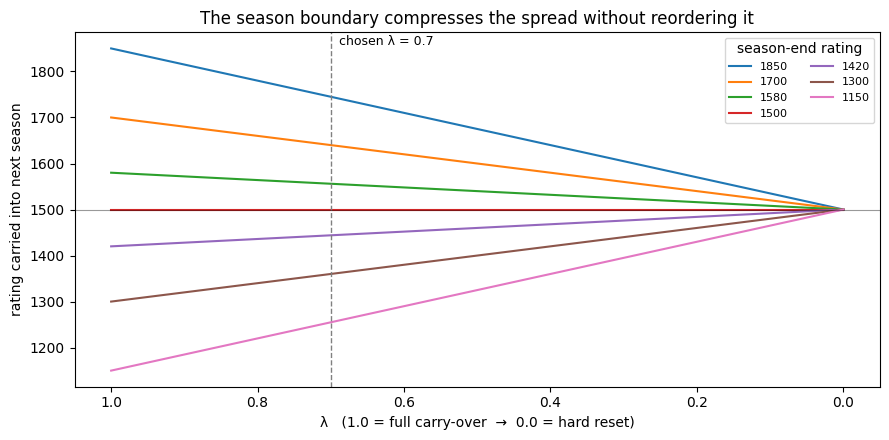

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for r in [1850, 1700, 1580, 1500, 1420, 1300, 1150]:
    lams = np.linspace(1, 0, 50)
    ax.plot(lams, [regress_to_mean(r, l) for l in lams], label=f"{r}")
ax.axvline(LAMBDA_REGRESSION, ls="--", lw=1, color="grey")
ax.text(LAMBDA_REGRESSION, 1880, f"  chosen λ = {LAMBDA_REGRESSION}", va="top", fontsize=9)
ax.axhline(RATING_MEAN, lw=0.8, color="black", alpha=0.4)
ax.set_xlabel("λ   (1.0 = full carry-over  →  0.0 = hard reset)")
ax.set_ylabel("rating carried into next season")
ax.set_title("The season boundary compresses the spread without reordering it")
ax.invert_xaxis()
ax.legend(title="season-end rating", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
## 5. Generating match data

No `matches.csv` here, so we simulate one. Each player gets a hidden *true skill*; match outcomes
are drawn from the Elo win probability implied by those true skills. That gives us a ground truth
to check the system against — a working seasonal rating should recover the true skill ordering.

**Chronological order is non-negotiable.** Elo is path-dependent: the same set of matches
processed in a different order produces different final ratings. If your real `matches.csv`
lacks a reliable timestamp, fix that before anything else, because every downstream number
is wrong otherwise.

In [7]:
@dataclass
class Match:
    match_id: str
    season_id: str
    played_at: datetime
    player_a: str
    player_b: str
    result: float          # 1.0 / 0.5 / 0.0 from A's perspective


PLAYERS = {
    # name        true skill
    "Alice":      1780,
    "Bob":        1655,
    "Charlie":    1590,
    "Dana":       1560,
    "Eve":        1520,
    "Frank":      1480,
    "Grace":      1430,
    "Hank":       1350,
    "Ivy":        1600,   # will play very few matches -> stays provisional
    "Jon":        1545,   # will go inactive mid-season
}


def simulate_season(season_id, start_date, n_days, n_matches, players=None,
                    draw_rate=0.08, activity=None, stops_at=None):
    """Generate a chronologically ordered season of matches from hidden true skills.

    activity : relative frequency per player (low value -> stays provisional)
    stops_at : {player: day_offset} -- player plays no matches after that day
    """
    players = players or PLAYERS
    activity = activity or {}
    stops_at = stops_at or {}

    rows = []
    for i in range(n_matches):
        day = random.uniform(0, n_days)

        # Only players still active on this day are eligible for this match.
        names = [n for n in players if day <= stops_at.get(n, float("inf"))]
        weights = [activity.get(n, 1.0) for n in names]

        a, b = random.choices(names, weights=weights, k=2)
        while a == b:
            b = random.choices(names, weights=weights, k=1)[0]

        p_a = expected_score(players[a], players[b])
        roll = random.random()
        if roll < draw_rate:
            result = 0.5
        else:
            result = 1.0 if random.random() < p_a else 0.0

        offset = timedelta(days=day, minutes=random.randint(0, 1439))
        rows.append(Match(f"{season_id}-M{i:04d}", season_id,
                          start_date + offset, a, b, result))

    rows.sort(key=lambda m: m.played_at)          # chronological, always
    for i, m in enumerate(rows):                  # re-id in time order
        m.match_id = f"{season_id}-M{i:04d}"
    return rows


# Ivy plays rarely -> she will stay provisional all season.
# Jon plays normally, then stops on day 55 -> he goes inactive (section 12).
ACTIVITY = {n: 1.0 for n in PLAYERS}
ACTIVITY["Ivy"] = 0.08
STOPS_AT = {"Jon": 55}

S1 = simulate_season("S1", datetime(2025, 1, 6), n_days=120, n_matches=320,
                     activity=ACTIVITY, stops_at=STOPS_AT)

matches_s1 = pd.DataFrame([asdict(m) for m in S1])
print(f"{len(S1)} matches, {matches_s1.played_at.min():%Y-%m-%d} → {matches_s1.played_at.max():%Y-%m-%d}")
matches_s1.head(8)

320 matches, 2025-01-06 → 2025-05-06


,match_id,season_id,played_at,player_a,player_b,result
0,S1-M0000,S1,2025-01-06 15:20:03.668382,Charlie,Dana,1.0
1,S1-M0001,S1,2025-01-06 15:49:52.635311,Dana,Jon,0.0
2,S1-M0002,S1,2025-01-07 05:22:22.479896,Dana,Frank,0.0
3,S1-M0003,S1,2025-01-07 09:43:10.604923,Hank,Grace,0.0
4,S1-M0004,S1,2025-01-07 10:58:12.306097,Bob,Jon,0.0
5,S1-M0005,S1,2025-01-07 21:34:33.475479,Hank,Grace,1.0
6,S1-M0006,S1,2025-01-08 11:26:48.545774,Grace,Frank,0.0
7,S1-M0007,S1,2025-01-09 04:19:23.091244,Alice,Eve,1.0


---
## 6. The season processing loop

The important part is not the rating math — it is the `rating_events` list.

Don't just store final ratings. Storing before/after for **every match** is what lets you:

- rebuild the leaderboard as of any date
- plot progression per player
- debug or settle a disputed result
- recompute the whole season after changing λ or the K schedule

It is an append-only event log, and the leaderboard is a materialized view over it. That is the
bronze → silver → gold shape, and it is what turns this from a script into a data platform.

In [8]:
def run_season(matches, starting_ratings=None, season_id="S1"):
    """Process one season chronologically. Returns (ratings, counts, rating_events)."""
    ratings = dict(starting_ratings or {})
    counts  = defaultdict(int)
    last_played = {}
    events  = []

    for m in sorted(matches, key=lambda x: x.played_at):
        a, b, s_a = m.player_a, m.player_b, m.result

        ra = ratings.get(a, INITIAL_RATING)
        rb = ratings.get(b, INITIAL_RATING)

        k = match_k(counts[a], counts[b])
        new_a, new_b = update_ratings(ra, rb, s_a, k=k)

        ratings[a], ratings[b] = new_a, new_b
        counts[a] += 1
        counts[b] += 1
        last_played[a] = last_played[b] = m.played_at

        for player, before, after, n in ((a, ra, new_a, counts[a]),
                                         (b, rb, new_b, counts[b])):
            events.append({
                "season_id": season_id,
                "match_id": m.match_id,
                "played_at": m.played_at,
                "player_id": player,
                "opponent_id": b if player == a else a,
                "result": s_a if player == a else 1.0 - s_a,
                "rating_before": before,
                "rating_after": after,
                "delta": after - before,
                "k_used": k,
                "matches_played_after": n,
            })

    # W/D/L, peak and rank are deliberately NOT tracked here -- they are all
    # derivable from the event log (section 7). One source of truth.
    meta = {"counts": dict(counts), "last_played": last_played}
    return ratings, meta, pd.DataFrame(events)


print(run_season.__doc__)

Process one season chronologically. Returns (ratings, counts, rating_events).


---
## 7. Building standings from the event log

`seasonal_standings` is derivable entirely from `rating_events`. Treat it as a rebuild-on-demand
table, **not** a source of truth.

A player below `MIN_MATCHES_FOR_RANKING` still *has* a rating — they are flagged `provisional` and
excluded from the ranked board. Don't hide them entirely; hiding them makes the data look broken
and makes "where am I?" unanswerable for a new participant.

In [9]:
def build_standings(events: pd.DataFrame, as_of: datetime = None,
                    min_matches: int = MIN_MATCHES_FOR_RANKING) -> pd.DataFrame:
    """Materialize the seasonal leaderboard from the rating-event log."""
    df = events if as_of is None else events[events.played_at <= as_of]
    if df.empty:
        return pd.DataFrame()

    last = (df.sort_values("played_at")
              .groupby("player_id")
              .tail(1)
              .set_index("player_id"))

    agg = df.groupby("player_id").agg(
        matches_played=("match_id", "count"),
        peak_rating=("rating_after", "max"),
        wins=("result", lambda s: (s == 1.0).sum()),
        draws=("result", lambda s: (s == 0.5).sum()),
        losses=("result", lambda s: (s == 0.0).sum()),
        last_played=("played_at", "max"),
    )

    out = agg.join(last[["rating_after"]].rename(columns={"rating_after": "rating"}))
    out["is_provisional"] = out.matches_played < min_matches
    out = out.sort_values(["is_provisional", "rating"], ascending=[True, False])

    # Rank *only* among eligible players, so numbering stays contiguous.
    eligible = ~out.is_provisional
    out["rank"] = np.nan
    out.loc[eligible, "rank"] = out.loc[eligible, "rating"].rank(
        ascending=False, method="min")
    cols = ["rank", "rating", "matches_played", "wins", "draws", "losses",
            "peak_rating", "is_provisional", "last_played"]
    return out[cols]


def show_board(standings, title):
    ranked = standings[~standings.is_provisional]
    prov   = standings[standings.is_provisional]
    print(f"\n{title}")
    print("=" * len(title))
    for p, r in ranked.iterrows():
        print(f"{int(r['rank']):>2}. {p:<9} {r.rating:>7.1f}   "
              f"({r.matches_played:>3} matches, {int(r.wins)}-{int(r.draws)}-{int(r.losses)})")
    if len(prov):
        print("-- provisional (unranked) --")
        for p, r in prov.iterrows():
            print(f"    {p:<9} {r.rating:>7.1f}   ({r.matches_played} matches)")

---
## 8. Running Season 1

Everyone starts at 1500 because there is no prior season.

In [10]:
ratings_s1, meta_s1, events_s1 = run_season(S1, starting_ratings=None, season_id="S1")

standings_s1 = build_standings(events_s1)
show_board(standings_s1, "Season 1 — final standings")


Season 1 — final standings
 1. Alice      1649.4   ( 84 matches, 60-6-18)
 2. Bob        1602.7   ( 68 matches, 44-3-21)
 3. Charlie    1574.8   ( 84 matches, 40-9-35)
 4. Dana       1571.8   ( 76 matches, 40-8-28)
 5. Jon        1509.4   ( 39 matches, 19-3-17)
 6. Eve        1444.1   ( 73 matches, 28-5-40)
 7. Frank      1424.1   ( 69 matches, 23-9-37)
 8. Grace      1398.5   ( 76 matches, 21-10-45)
 9. Hank       1346.6   ( 67 matches, 13-9-45)
-- provisional (unranked) --
    Ivy        1478.6   (4 matches)


In [11]:
# Did the system recover the hidden true skills?
check = (standings_s1[["rating", "matches_played", "is_provisional"]]
         .assign(true_skill=lambda d: d.index.map(PLAYERS))
         .assign(error=lambda d: d.rating - d.true_skill)
         .sort_values("true_skill", ascending=False))

ranked_only = check[~check.is_provisional]
corr = ranked_only.rating.corr(ranked_only.true_skill, method="spearman")
print(f"Spearman correlation (ranked players only): {corr:.3f}")
print(f"Mean absolute error: {ranked_only.error.abs().mean():.1f} rating points\n")
check

Spearman correlation (ranked players only): 1.000
Mean absolute error: 45.8 rating points



,rating,matches_played,is_provisional,true_skill,error
player_id,,,,,
Alice,"1,649.4",84,False,1780,-130.6
Bob,"1,602.7",68,False,1655,-52.3
Ivy,"1,478.6",4,True,1600,-121.4
Charlie,"1,574.8",84,False,1590,-15.2
Dana,"1,571.8",76,False,1560,11.8
Jon,"1,509.4",39,False,1545,-35.6
Eve,"1,444.1",73,False,1520,-75.9
Frank,"1,424.1",69,False,1480,-55.9
Grace,"1,398.5",76,False,1430,-31.5


Note where the error is largest — it will be the players with the fewest matches. That is the
system behaving correctly: a rating is a *claim with a confidence attached*, and few matches means
a weak claim. It is also exactly why `MIN_MATCHES_FOR_RANKING` exists.

---
## 9. Crossing the boundary into Season 2

Apply the regression, reset every match counter to zero. The first ten matches of the new season
then move fast under `K = 48`.

In [12]:
s2_start = apply_boundary(ratings_s1, lam=LAMBDA_REGRESSION)

boundary = (pd.DataFrame({"season_1_end": ratings_s1, "season_2_start": s2_start})
              .assign(change=lambda d: d.season_2_start - d.season_1_end)
              .sort_values("season_1_end", ascending=False))

spread_before = boundary.season_1_end.max() - boundary.season_1_end.min()
spread_after  = boundary.season_2_start.max() - boundary.season_2_start.min()
print(f"spread before: {spread_before:.0f}   after: {spread_after:.0f}   "
      f"(compressed {1 - spread_after/spread_before:.0%})")
boundary

spread before: 303   after: 212   (compressed 30%)


,season_1_end,season_2_start,change
Alice,"1,649.4","1,604.6",-44.8
Bob,"1,602.7","1,571.9",-30.8
Charlie,"1,574.8","1,552.4",-22.4
Dana,"1,571.8","1,550.3",-21.6
Jon,"1,509.4","1,506.6",-2.8
Ivy,"1,478.6","1,485.0",6.4
Eve,"1,444.1","1,460.8",16.8
Frank,"1,424.1","1,446.9",22.8
Grace,"1,398.5","1,429.0",30.4
Hank,"1,346.6","1,392.6",46.0


In [13]:
S2 = simulate_season("S2", datetime(2025, 6, 2), n_days=120, n_matches=320,
                     activity=ACTIVITY, stops_at=STOPS_AT)

ratings_s2, meta_s2, events_s2 = run_season(S2, starting_ratings=s2_start, season_id="S2")
standings_s2 = build_standings(events_s2)
show_board(standings_s2, "Season 2 — final standings")


Season 2 — final standings
 1. Alice      1745.0   ( 85 matches, 68-4-13)
 2. Bob        1601.3   ( 77 matches, 49-2-26)
 3. Charlie    1519.0   ( 82 matches, 40-6-36)
 4. Dana       1509.9   ( 72 matches, 32-6-34)
 5. Jon        1496.6   ( 23 matches, 11-0-12)
 6. Eve        1453.5   ( 68 matches, 28-6-34)
 7. Frank      1436.3   ( 90 matches, 30-3-57)
 8. Grace      1384.7   ( 74 matches, 24-5-45)
 9. Hank       1326.1   ( 60 matches, 14-5-41)
-- provisional (unranked) --
    Ivy        1527.7   (9 matches)


---
## 10. Rating progression

Two views. The first is within-season trajectories; the second stitches both seasons together so
the boundary discontinuity is visible.

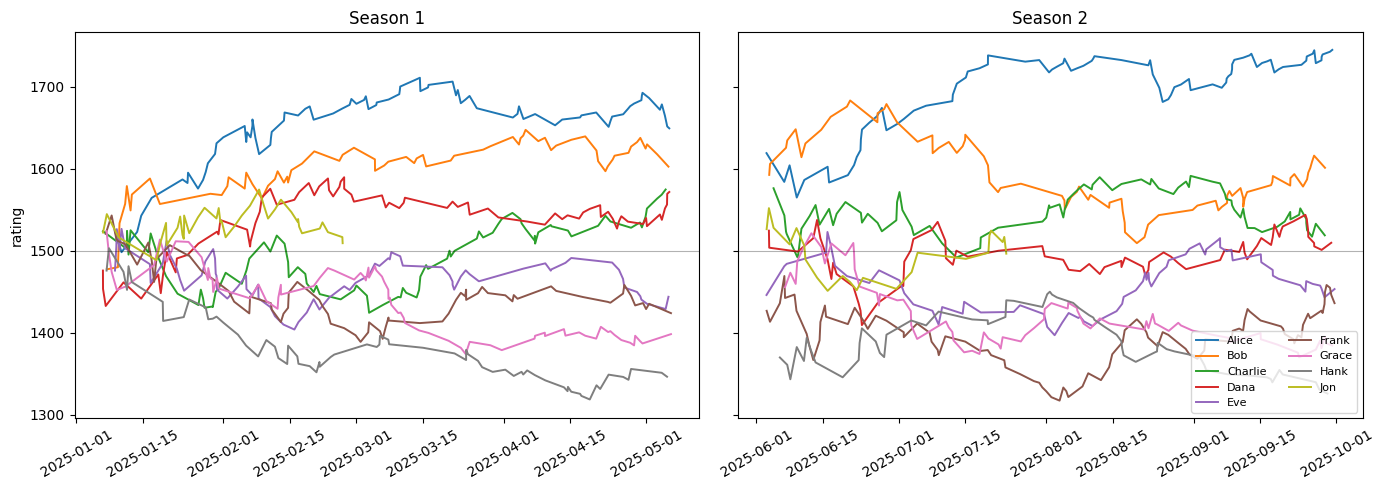

In [14]:
def progression(events, player):
    d = events[events.player_id == player].sort_values("played_at")
    return d.played_at.tolist(), d.rating_after.tolist()


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (ev, name) in zip(axes, [(events_s1, "Season 1"), (events_s2, "Season 2")]):
    for p in PLAYERS:
        x, y = progression(ev, p)
        if len(x) >= MIN_MATCHES_FOR_RANKING:
            ax.plot(x, y, lw=1.4, label=p)
    ax.axhline(RATING_MEAN, lw=0.8, color="black", alpha=0.3)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("rating")
axes[1].legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.show()

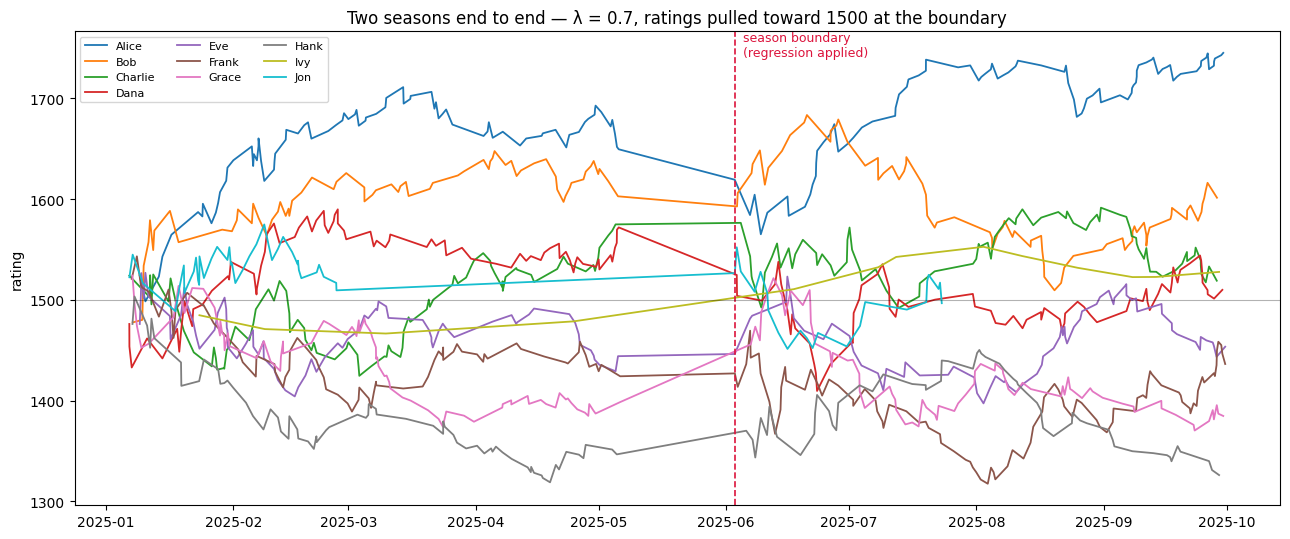

In [15]:
all_events = pd.concat([events_s1, events_s2], ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
for p in PLAYERS:
    x, y = progression(all_events, p)
    if len(x) >= MIN_MATCHES_FOR_RANKING:
        ax.plot(x, y, lw=1.3, label=p)

boundary_date = pd.Timestamp(events_s2.played_at.min())
ax.axvline(boundary_date, ls="--", lw=1.2, color="crimson")
ax.text(boundary_date, ax.get_ylim()[1], "  season boundary\n  (regression applied)",
        va="top", fontsize=9, color="crimson")
ax.axhline(RATING_MEAN, lw=0.8, color="black", alpha=0.3)
ax.set_ylabel("rating")
ax.set_title(f"Two seasons end to end — λ = {LAMBDA_REGRESSION}, ratings pulled toward "
             f"{RATING_MEAN:.0f} at the boundary")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

The vertical collapse at the red line is the boundary doing its job: the fan of ratings narrows,
but no lines cross each other at that instant. Re-run this notebook with `LAMBDA_REGRESSION = 1.0`
and the discontinuity disappears entirely — along with any distinction between the seasonal
rating and the overall rating.

---
## 11. Replay — rebuilding standings as of any date

This is the payoff for keeping the event log. The leaderboard at any point in history is a filter
plus a group-by. No separate snapshot table, no nightly job, nothing to drift out of sync.

In [16]:
for week in (2, 6, 12, 18):
    as_of = events_s1.played_at.min() + timedelta(weeks=week)
    board = build_standings(events_s1, as_of=as_of)
    show_board(board, f"Season 1 — standings as of week {week} ({as_of:%Y-%m-%d})")


Season 1 — standings as of week 2 (2025-01-20)
 1. Bob        1557.1   ( 10 matches, 6-1-3)
 2. Eve        1512.2   ( 10 matches, 5-0-5)
 3. Frank      1489.9   ( 10 matches, 4-2-4)
-- provisional (unranked) --
    Alice      1564.6   (5 matches)
    Jon        1506.7   (7 matches)
    Dana       1498.6   (9 matches)
    Grace      1486.9   (8 matches)
    Charlie    1469.2   (9 matches)
    Hank       1414.6   (8 matches)

Season 1 — standings as of week 6 (2025-02-17)
 1. Alice      1665.0   ( 29 matches, 21-3-5)
 2. Bob        1606.4   ( 26 matches, 16-3-7)
 3. Dana       1571.6   ( 26 matches, 14-3-9)
 4. Jon        1521.4   ( 34 matches, 17-3-14)
 5. Charlie    1480.1   ( 29 matches, 12-3-14)
 6. Frank      1462.2   ( 26 matches, 9-4-13)
 7. Grace      1446.8   ( 26 matches, 9-3-14)
 8. Eve        1413.2   ( 33 matches, 12-1-20)
 9. Hank       1362.4   ( 25 matches, 5-3-17)
-- provisional (unranked) --
    Ivy        1470.9   (2 matches)

Season 1 — standings as of week 12 (2025-

In [17]:
# Full replay under different parameters, from the same raw matches.
comparison = {}
for lam in (1.00, 0.70, 0.30, 0.00):
    start = apply_boundary(ratings_s1, lam=lam)
    r2, _, _ = run_season(S2, starting_ratings=start, season_id="S2")
    comparison[f"λ={lam:.2f}"] = r2

pd.DataFrame(comparison).sort_values("λ=0.70", ascending=False)

,λ=1.00,λ=0.70,λ=0.30,λ=0.00
Alice,"1,749.9","1,745.0","1,739.6","1,736.0"
Bob,"1,603.7","1,601.3","1,598.6","1,596.9"
Ivy,"1,522.9","1,527.7","1,534.0","1,538.7"
Charlie,"1,521.7","1,519.0","1,515.7","1,513.4"
Dana,"1,510.8","1,509.9","1,508.7","1,507.8"
Jon,"1,502.1","1,496.6","1,489.8","1,484.8"
Eve,"1,452.3","1,453.5","1,454.7","1,455.5"
Frank,"1,435.5","1,436.3","1,437.1","1,437.5"
Grace,"1,382.0","1,384.7","1,387.9","1,390.0"
Hank,"1,319.2","1,326.1","1,334.0","1,339.3"


Ratings converge across λ values for players with many matches — enough evidence washes out the
starting point. The difference persists for low-volume players, which is the honest result: with
little data, where you started still dominates what you have proven.

---
## 12. Inactivity

Optional, but worth having if seasons are long. Two approaches:

1. **Decay the rating** toward the mean after N days idle. Punishes rank-camping — winning early
   then refusing to play to protect a top spot.
2. **Leave the rating alone, drop them from the active board.**

The second is cleaner and less controversial. Decaying a rating for non-participation conflates
*"is inactive"* with *"is weaker"*, which is a different claim and one the match data does not
support. Use option 1 only if rank-camping is a demonstrated problem in your competition.

In [18]:
def flag_inactive(standings, as_of: datetime, days: int = INACTIVITY_DAYS):
    """Mark players with no match in the window. Rating untouched."""
    out = standings.copy()
    out["days_idle"] = (as_of - out.last_played).dt.days
    out["is_inactive"] = out.days_idle > days
    return out


def active_board(standings, as_of: datetime, days: int = INACTIVITY_DAYS):
    f = flag_inactive(standings, as_of, days)
    live = f[(~f.is_inactive) & (~f.is_provisional)].copy()
    live["rank"] = live.rating.rank(ascending=False, method="min")
    return live.sort_values("rating", ascending=False)


season_end = events_s2.played_at.max()
flagged = flag_inactive(standings_s2, season_end)
flagged[["rating", "matches_played", "days_idle", "is_inactive", "is_provisional"]]

,rating,matches_played,days_idle,is_inactive,is_provisional
player_id,,,,,
Alice,"1,745.0",85,0,False,False
Bob,"1,601.3",77,2,False,False
Charlie,"1,519.0",82,2,False,False
Dana,"1,509.9",72,0,False,False
Jon,"1,496.6",23,69,True,False
Eve,"1,453.5",68,0,False,False
Frank,"1,436.3",90,0,False,False
Grace,"1,384.7",74,0,False,False
Hank,"1,326.1",60,1,False,False


In [19]:
# Optional variant: decay instead of flagging. Shown for comparison, not used by default.
def decay_toward_mean(rating, days_idle, days_before_decay=INACTIVITY_DAYS,
                      rate_per_30d=0.04, mean=RATING_MEAN):
    if days_idle <= days_before_decay:
        return rating
    periods = (days_idle - days_before_decay) / 30.0
    pull = 1.0 - (1.0 - rate_per_30d) ** periods
    return rating + pull * (mean - rating)


pd.DataFrame({
    "days_idle": [0, 30, 60, 90, 180, 365],
}).assign(
    rating_1800=lambda d: d.days_idle.map(lambda x: decay_toward_mean(1800, x)),
    rating_1300=lambda d: d.days_idle.map(lambda x: decay_toward_mean(1300, x)),
)

,days_idle,rating_1800,rating_1300
0,0,"1,800.0","1,300.0"
1,30,"1,800.0","1,300.0"
2,60,"1,788.0","1,308.0"
3,90,"1,776.5","1,315.7"
4,180,"1,744.6","1,336.9"
5,365,"1,690.2","1,373.2"


---
## 13. Persisting the schema

```
seasons(season_id, name, start_date, end_date,
        lambda_regression, initial_rating,
        k_provisional, k_settling, k_established,
        min_matches_for_ranking)

match_events(match_id, season_id, played_at, player_a, player_b, result)

rating_events(event_id, season_id, match_id, played_at, player_id, opponent_id,
              result, rating_before, rating_after, delta, k_used,
              matches_played_after)

seasonal_standings(season_id, player_id, rating, matches_played,
                   wins, draws, losses, peak_rating, is_provisional, last_played)
```

`match_events` is the raw fact table. `rating_events` is the derived, append-only log.
`seasonal_standings` is a view — rebuildable from `rating_events` at any time, which is why the
season parameters are stored on the `seasons` row rather than living in code.

In [20]:
import os

os.makedirs("data", exist_ok=True)

seasons = pd.DataFrame([
    {"season_id": "S1", "name": "2025 Spring",
     "start_date": min(m.played_at for m in S1), "end_date": max(m.played_at for m in S1)},
    {"season_id": "S2", "name": "2025 Autumn",
     "start_date": min(m.played_at for m in S2), "end_date": max(m.played_at for m in S2)},
]).assign(
    lambda_regression=LAMBDA_REGRESSION,
    initial_rating=INITIAL_RATING,
    k_provisional=K_PROVISIONAL,
    k_settling=K_SETTLING,
    k_established=K_ESTABLISHED,
    min_matches_for_ranking=MIN_MATCHES_FOR_RANKING,
)

match_events = pd.concat(
    [pd.DataFrame([asdict(m) for m in S1]), pd.DataFrame([asdict(m) for m in S2])],
    ignore_index=True,
)

rating_events = all_events.copy()
rating_events.insert(0, "event_id", [f"E{i:06d}" for i in range(len(rating_events))])

seasonal_standings = pd.concat([
    standings_s1.assign(season_id="S1").reset_index(),
    standings_s2.assign(season_id="S2").reset_index(),
], ignore_index=True)

for name, df in [("seasons", seasons), ("match_events", match_events),
                 ("rating_events", rating_events),
                 ("seasonal_standings", seasonal_standings)]:
    path = f"data/{name}.csv"
    df.to_csv(path, index=False)
    print(f"{path:<34} {len(df):>6} rows")

data/seasons.csv                        2 rows
data/match_events.csv                 640 rows
data/rating_events.csv               1280 rows
data/seasonal_standings.csv            20 rows


In [21]:
# Proof the standings table is fully derivable: rebuild it and diff.
rebuilt = build_standings(rating_events[rating_events.season_id == "S2"])
delta = (rebuilt.rating - standings_s2.rating).abs().max()
print(f"max rating difference on rebuild: {delta:.10f}")
assert delta < 1e-9, "standings are NOT reproducible from the event log"
print("seasonal_standings is a pure function of rating_events ✓")

max rating difference on rebuild: 0.0000000000
seasonal_standings is a pure function of rating_events ✓


---
## 14. Where this connects to the other three ratings

Being straight about it: seasonal rating on its own is the weakest of the four, conceptually.
It is Elo plus a reset policy. What makes it worth building carefully is that it is the substrate
the other three sit on:

| Rating | What it reads from `rating_events` |
|---|---|
| **Seasonal** | the log itself, filtered to one `season_id` |
| **Overall** | the same matches without the boundary regression — un-regressed accumulation |
| **Prosperity** | season-over-season deltas, volatility of `delta`, consistency of `k_used` tier progression |
| **Thinkers** | strategy-change markers joined against the `delta` that followed them |

If the seasonal event log is clean and replayable, the other three are mostly queries over it.
If it is not, all four are built on sand.

So the effort belongs in `rating_events` and `run_season` / `build_standings` — not in the
seasonal formula, which is six lines.

### Next steps for the repo

1. Move `expected_score`, `update_ratings`, `k_factor` into `src/elo.py`
2. Move `run_season`, `build_standings`, `apply_boundary` into `src/ranking.py`
3. Replace the simulator with a `data/matches.csv` loader that **validates timestamps are present
   and total-ordered** before processing
4. Swap the CSV writes for a real store; `rating_events` is append-only, which makes it a clean
   fit for partitioned Parquet or a Delta table partitioned by `season_id`
5. Expose `GET /standings?season_id=&as_of=` — the `as_of` replay in section 11 is already the
   whole endpoint